# Identity Hate

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_DIR = Path("data")
data = pd.read_parquet(DATA_DIR / "dense_engineered_train.parquet")

toxic = data["toxic"]
severe_toxic = data["severe_toxic"]
obscene = data["obscene"]
threat = data["threat"]
insult = data["insult"]
identity_hate = data["identity_hate"]

X_train = data.drop(
    columns=[
        "id",
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate",
    ]
)

y_train = identity_hate

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=1234
)

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

FileNotFoundError: [Errno 2] No such file or directory: 'data\\dense_engineered_train.parquet'

# Baseline Models 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

log = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=0.1, class_weight="balanced")),
    ]
)

mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(100, 50),
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                random_state=1234,
            ),
        ),
    ]
)

rf = Pipeline(
    [
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                n_jobs=-1,
                random_state=1234,
                class_weight="balanced",
            ),
        )
    ]
)

hgb = Pipeline(
    [
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                early_stopping=True,
                random_state=1234,
            ),
        )
    ]
)

models = {
    "Logistic Regression": log,
    "Random Forest": rf,
    "Hist Gradient Boosting": hgb,
    "Neural Networks": mlp,
}

# Baseline Results

In [ ]:
import time
from sklearn.metrics import average_precision_score, precision_recall_curve

results = {}

for name, model in models.items():

    start_train = time.time()
    if name == "Hist Gradient Boosting":
        model.fit(X_tr, y_tr, model__sample_weight=sample_weights)
    else:
        model.fit(X_tr, y_tr)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_score = model.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred

    ap = average_precision_score(y_val, y_score)
    precision, recall, _ = precision_recall_curve(y_val, y_score)

    results[name] = {
        "model": model,
        "y_score": y_score,
        "ap": ap,
        "precision": precision,
        "recall": recall,
        "train_time": train_time,
        "pred_time": pred_time,
    }

    print(f"{name}:")
    print(f"  AP      = {ap:.4f}")
    print(f"  Train   = {train_time:.2f}")
    print(f"  Predict = {pred_time:.2f}")

Logistic Regression:
  AP      = 0.0937
  Train   = 0.93
  Predict = 0.01
Random Forest:
  AP      = 0.1227
  Train   = 11.33
  Predict = 0.16
Hist Gradient Boosting:
  AP      = 0.1118
  Train   = 1.19
  Predict = 0.03
Neural Networks:
  AP      = 0.1360
  Train   = 5.22
  Predict = 0.02


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

In [ ]:
from sklearn.model_selection import GridSearchCV

log_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

log_search = GridSearchCV(
    estimator=log,
    param_grid=log_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

log_search.fit(X_tr, y_tr)
print(log_search.best_params_)
print(log_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'model__C': 0.01, 'model__class_weight': 'balanced'}
0.1017265906885441


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

mlp_dist = {
    "model__hidden_layer_sizes": [
        (32, 16),
        (64, 32),
        (100, 50),
        (128, 64),
        (128, 64, 32),
    ],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
    "model__activation": ["relu", "tanh"],
    "model__batch_size": [64, 128],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=mlp_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=1234,
)

mlp_search.fit(X_tr, y_tr)
print(mlp_search.best_params_)
print(mlp_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (100, 50), 'model__batch_size': 128, 'model__alpha': 0.0001, 'model__activation': 'tanh'}
0.12818262798818325


# Tuned Models

In [ ]:
log = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=0.01, class_weight="balanced")),
    ]
)

mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(100, 50),
                alpha=1e-4,
                batch_size=128,
                activation="tanh",
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                random_state=1234,
            ),
        ),
    ]
)

models = {"Logistic Regression": log, "Neural Networks": mlp}

results = {}

for name, model in models.items():

    start_train = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_score = model.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred

    ap = average_precision_score(y_val, y_score)
    precision, recall, _ = precision_recall_curve(y_val, y_score)

    results[name] = {
        "model": model,
        "y_score": y_score,
        "ap": ap,
        "precision": precision,
        "recall": recall,
        "train_time": train_time,
        "pred_time": pred_time,
    }

    print(f"{name}:")
    print(f"  AP      = {ap:.4f}")
    print(f"  Train   = {train_time:.2f}")
    print(f"  Predict = {pred_time:.2f}")

Logistic Regression:
  AP      = 0.0943
  Train   = 0.80
  Predict = 0.02
Neural Networks:
  AP      = 0.1073
  Train   = 6.56
  Predict = 0.05


# Visualization

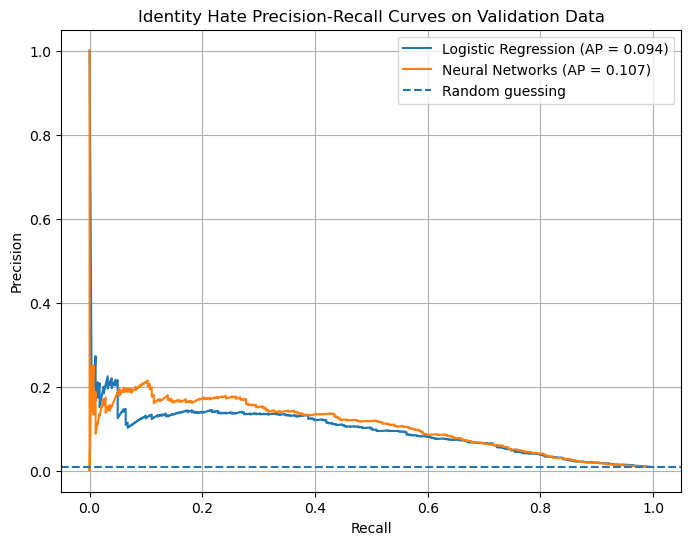

In [ ]:
import matplotlib.pyplot as plt

baseline = y_val.mean()

plt.figure(figsize=(8, 6))

for name, res in results.items():
    plt.plot(res["recall"], res["precision"], label=f"{name} (AP = {res['ap']:.3f})")

plt.axhline(y=baseline, linestyle="--", label="Random guessing")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Identity Hate Precision-Recall Curves on Validation Data")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# I point to the project data folder.
DATA_DIR = Path("data")
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "dense_engineered_train.parquet"
TEST_PATH = DATA_DIR / "dense_engineered_test.parquet"
OUTPUT_PATH = OUTPUT_DIR / "best_ap_identity_hate_test_predictions.parquet"

# I reload the full train and test data so this cell is self-contained.
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

# I rebuild full train features and labels.
X_full_train = train_df.drop(
    columns=[
        "id",
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate",
    ]
)
y_full_train = train_df["identity_hate"]

# I keep test ids and features.
test_ids = test_df["id"].copy()
X_test = test_df.drop(columns=["id"])

# I choose the best final model from the validation comparison above.
# I expect the earlier notebook cell to have populated `results`.
best_model_name = max(results, key=lambda name: results[name]["ap"])
best_model = results[best_model_name]["model"]

print(f"Best final validation model: {best_model_name}")
print(f"Best validation AP: {results[best_model_name]['ap']:.6f}")

# I retrain the winner on the full training data.
best_model.fit(X_full_train, y_full_train)

# I score the test set.
test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# I save only what we need for downstream merge work.
test_predictions = pd.DataFrame(
    {
        "id": test_ids,
        "pred_identity_hate": test_pred
    }
)

test_predictions.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(test_predictions.head())